# Homework 4 — Task 2: Sequence Models on Air Passengers Dataset

**Dataset:** International Airline Passengers (1949–1960)  
**Source:** https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv  
*(Also available on Kaggle: https://www.kaggle.com/datasets/rakannimer/air-passengers)*

## Why Sequence Models?

Time-series data like monthly passenger counts has temporal dependencies — each month's passenger count is influenced by previous months (trends, seasonality). A standard feed-forward network treats each input independently and cannot capture these temporal patterns. Sequence models (RNN, LSTM, GRU) maintain a hidden state that propagates information across time steps, making them naturally suited for forecasting tasks where the order of data points matters.

Problem: Predict the number of international airline passengers for future months given a window of past months.

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

#Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Data Loading & Visualization

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, header=0, names=['Month', 'Passengers'], parse_dates=['Month'])
df.set_index('Month', inplace=True)

print('Shape:', df.shape)
print('Date range:', df.index.min(), 'to', df.index.max())
print('\nFirst 5 rows:')
df.head()

Shape: (144, 1)
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00

First 5 rows:


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


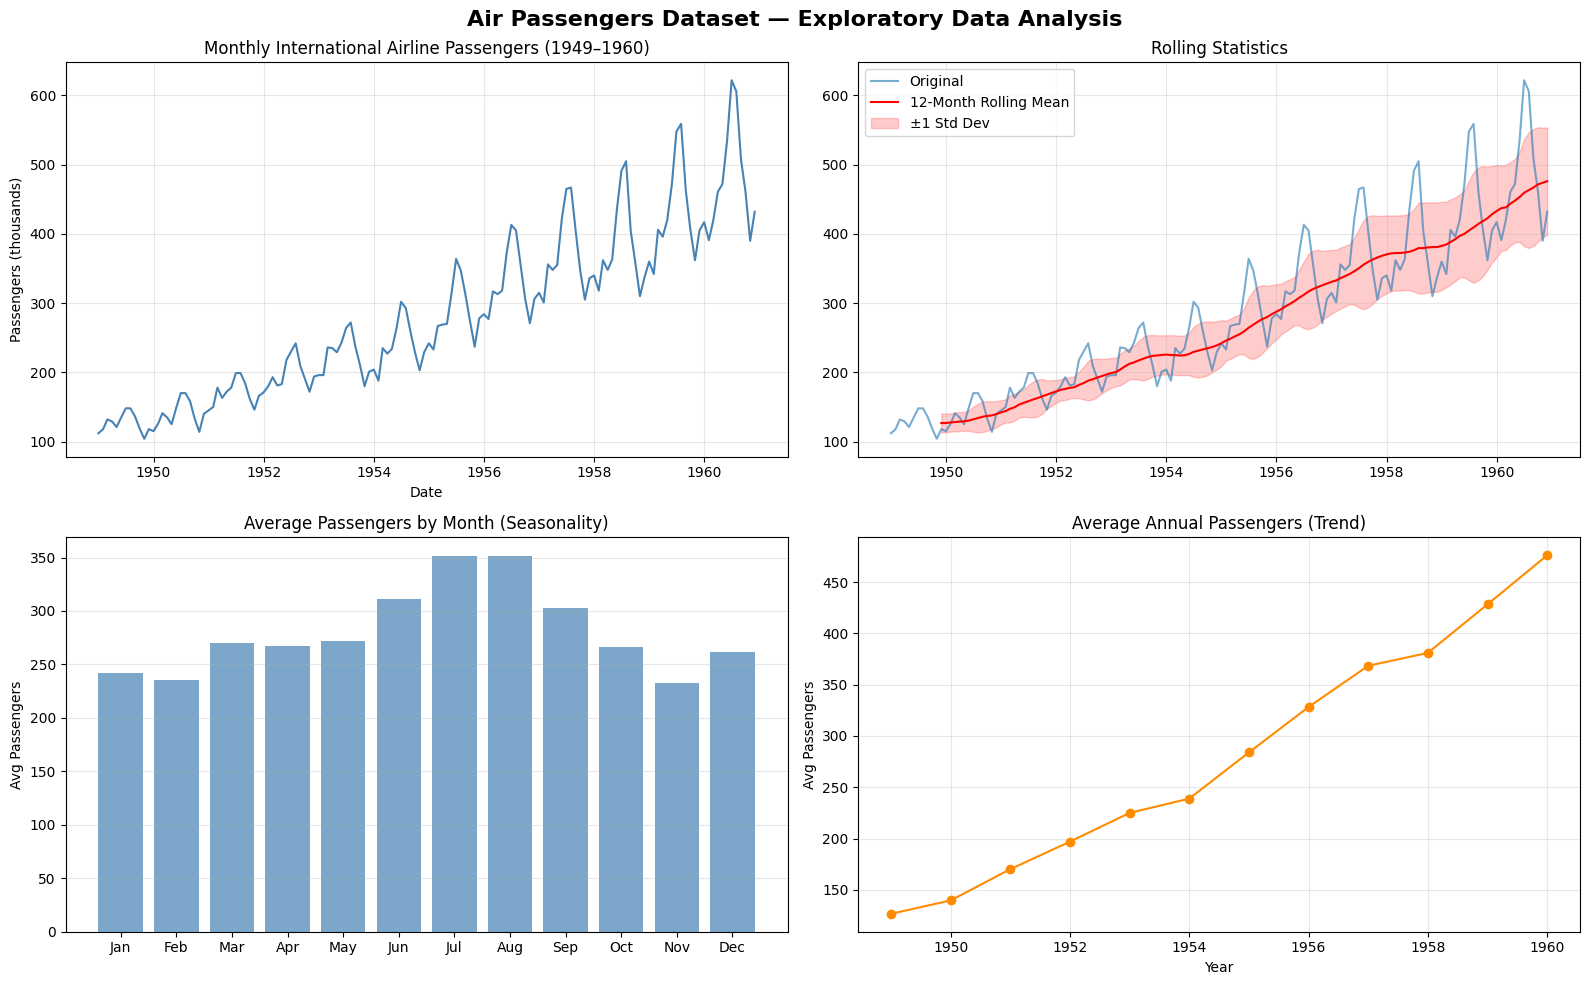


Key Observations:
1. Clear upward trend in passenger numbers over time
2. Strong yearly seasonality — peaks in July/August
3. Increasing variance (multiplicative seasonality) — log transform may help
4. No missing values: 0


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Air Passengers Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold')

#Raw time series
axes[0, 0].plot(df.index, df['Passengers'], color='steelblue', linewidth=1.5)
axes[0, 0].set_title('Monthly International Airline Passengers (1949–1960)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Passengers (thousands)')
axes[0, 0].grid(alpha=0.3)
#Rolling mean & std
rolling_mean = df['Passengers'].rolling(12).mean()
rolling_std  = df['Passengers'].rolling(12).std()
axes[0, 1].plot(df['Passengers'], label='Original', alpha=0.6)
axes[0, 1].plot(rolling_mean, label='12-Month Rolling Mean', color='red')
axes[0, 1].fill_between(df.index,
                         rolling_mean - rolling_std,
                         rolling_mean + rolling_std,
                         alpha=0.2, color='red', label='±1 Std Dev')
axes[0, 1].set_title('Rolling Statistics')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
#Monthly seasonality
df['Month_num'] = df.index.month
monthly_avg = df.groupby('Month_num')['Passengers'].mean()
axes[1, 0].bar(range(1, 13), monthly_avg.values, color='steelblue', alpha=0.7)
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1, 0].set_title('Average Passengers by Month (Seasonality)')
axes[1, 0].set_ylabel('Avg Passengers')
axes[1, 0].grid(alpha=0.3, axis='y')
#Yearly growth
df['Year'] = df.index.year
yearly_avg = df.groupby('Year')['Passengers'].mean()
axes[1, 1].plot(yearly_avg.index, yearly_avg.values, marker='o', color='darkorange')
axes[1, 1].set_title('Average Annual Passengers (Trend)')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Avg Passengers')
axes[1, 1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('\nKey Observations:')
print('1. Clear upward trend in passenger numbers over time')
print('2. Strong yearly seasonality — peaks in July/August')
print('3. Increasing variance (multiplicative seasonality) — log transform may help')
print('4. No missing values:', df['Passengers'].isnull().sum())

## 3. Data Preprocessing & Feature Engineering

In [4]:
#Log transform to stabilize variance
data = np.log(df['Passengers'].values).reshape(-1, 1)
#Normalize to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)
#Train/Val/Test split (70% / 15% / 15%)
n = len(data_scaled)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)
train_data = data_scaled[:train_end]
val_data   = data_scaled[train_end:val_end]
test_data  = data_scaled[val_end:]
print(f'Total samples: {n}')
print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

def create_sequences(data, seq_len=12):
    """Create sliding window sequences for time-series forecasting."""
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 12#Use 12 months as lookback window
X_train, y_train = create_sequences(train_data, SEQ_LEN)
X_val,   y_val   = create_sequences(val_data,   SEQ_LEN)
X_test,  y_test  = create_sequences(test_data,  SEQ_LEN)
#Convert to tensors
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t   = torch.FloatTensor(X_val).to(device)
y_val_t   = torch.FloatTensor(y_val).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)
print(f'\nSequence shapes — X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'Each input: {SEQ_LEN} time steps → predict 1 step ahead')

Total samples: 144
Train: 100 | Val: 22 | Test: 22

Sequence shapes — X_train: (88, 12, 1), y_train: (88, 1)
Each input: 12 time steps → predict 1 step ahead


---
## Part 1: Vanilla RNN

**Architecture:**
- Input: sequence of 12 monthly passenger counts (scaled)
- RNN Layer: 1 layer, 64 hidden units, `tanh` activation at each time step
- Fully Connected Output Layer: 64 → 1, linear activation
- Loss Function: Mean Squared Error (MSE)
- Metric: Root Mean Squared Error (RMSE) — interpretable in original units after inverse transform

**Activation functions:**
- Each RNN time step: `tanh` (PyTorch default for RNN)
- Output layer: Linear (regression task)

In [5]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        #tanh activation used at each time step (nonlinearity='tanh')
        self.rnn = nn.RNN(input_size, hidden_size, num_layers,
                          batch_first=True, nonlinearity='tanh')
        self.fc  = nn.Linear(hidden_size, output_size)  # linear output

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])  # Take last time step
        return out

def train_model(model, X_train, y_train, X_val, y_val,
                epochs=200, lr=0.001, batch_size=16):
    """Generic training loop with val loss tracking."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    dataset   = TensorDataset(X_train, y_train)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(loader))
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()
        val_losses.append(val_loss)
        if (epoch + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{epochs}]  Train Loss: {train_losses[-1]:.6f}  Val Loss: {val_losses[-1]:.6f}')
    return train_losses, val_losses


def evaluate_model(model, X, y, scaler, label='Test'):
    """Evaluate model and return RMSE and MAE in original (log-inverse) scale."""
    model.eval()
    with torch.no_grad():
        preds = model(X).cpu().numpy()
    y_np  = y.cpu().numpy()
    #Inverse scale then inverse log
    preds_orig = np.exp(scaler.inverse_transform(preds))
    y_orig     = np.exp(scaler.inverse_transform(y_np))
    rmse = np.sqrt(mean_squared_error(y_orig, preds_orig))
    mae  = mean_absolute_error(y_orig, preds_orig)
    print(f'{label} RMSE: {rmse:.2f}  |  {label} MAE: {mae:.2f}')
    return rmse, mae, preds_orig, y_orig

#Instantiate and train Vanilla RNN
print('=== Vanilla RNN ===')
rnn_model = VanillaRNN().to(device)
print(rnn_model)
print(f'\nTotal params: {sum(p.numel() for p in rnn_model.parameters()):,}')

=== Vanilla RNN ===
VanillaRNN(
  (rnn): RNN(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total params: 4,353


In [6]:
rnn_train_losses, rnn_val_losses = train_model(
    rnn_model, X_train_t, y_train_t, X_val_t, y_val_t, epochs=200
)

Epoch [50/200]  Train Loss: 0.003449  Val Loss: 0.010677
Epoch [100/200]  Train Loss: 0.003079  Val Loss: 0.005004
Epoch [150/200]  Train Loss: 0.001496  Val Loss: 0.002152
Epoch [200/200]  Train Loss: 0.001380  Val Loss: 0.001402


In [7]:
print('--- Vanilla RNN Performance ---')
rnn_val_rmse, rnn_val_mae, _, _ = evaluate_model(rnn_model, X_val_t, y_val_t, scaler, 'Validation')
rnn_test_rmse, rnn_test_mae, rnn_preds, rnn_actual = evaluate_model(rnn_model, X_test_t, y_test_t, scaler, 'Test')

--- Vanilla RNN Performance ---
Validation RMSE: 28.12  |  Validation MAE: 24.42
Test RMSE: 64.05  |  Test MAE: 55.81


---
## Part 2: LSTM and GRU

### LSTM (Long Short-Term Memory)
LSTMs use a cell state and three gates (input, forget, output) with sigmoid activations for gating and tanh for candidate values. This allows LSTMs to selectively remember or forget information over long sequences, addressing the vanishing gradient problem.

### GRU (Gated Recurrent Unit)
GRUs are a simplified version of LSTM with only two gates (reset, update), also using sigmoid and tanh activations. They have fewer parameters than LSTM while achieving comparable performance.

In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        #Gates use sigmoid; candidate values use tanh
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        #Reset & update gates use sigmoid; candidate uses tanh
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        return self.fc(out[:, -1, :])


#Train LSTM
print('=== LSTM ===')
lstm_model = LSTMModel().to(device)
lstm_train_losses, lstm_val_losses = train_model(
    lstm_model, X_train_t, y_train_t, X_val_t, y_val_t, epochs=200
)
print('\n--- LSTM Performance ---')
lstm_val_rmse, lstm_val_mae, _, _ = evaluate_model(lstm_model, X_val_t, y_val_t, scaler, 'Validation')
lstm_test_rmse, lstm_test_mae, lstm_preds, lstm_actual = evaluate_model(lstm_model, X_test_t, y_test_t, scaler, 'Test')

=== LSTM ===
Epoch [50/200]  Train Loss: 0.005934  Val Loss: 0.007965
Epoch [100/200]  Train Loss: 0.004321  Val Loss: 0.008850
Epoch [150/200]  Train Loss: 0.002525  Val Loss: 0.003662
Epoch [200/200]  Train Loss: 0.001741  Val Loss: 0.002458

--- LSTM Performance ---
Validation RMSE: 35.67  |  Validation MAE: 30.82
Test RMSE: 64.14  |  Test MAE: 53.24


In [9]:
#Train GRU
print('=== GRU ===')
gru_model = GRUModel().to(device)
gru_train_losses, gru_val_losses = train_model(
    gru_model, X_train_t, y_train_t, X_val_t, y_val_t, epochs=200
)
print('\n--- GRU Performance ---')
gru_val_rmse, gru_val_mae, _, _ = evaluate_model(gru_model, X_val_t, y_val_t, scaler, 'Validation')
gru_test_rmse, gru_test_mae, gru_preds, gru_actual = evaluate_model(gru_model, X_test_t, y_test_t, scaler, 'Test')

=== GRU ===
Epoch [50/200]  Train Loss: 0.004096  Val Loss: 0.007118
Epoch [100/200]  Train Loss: 0.003205  Val Loss: 0.004499
Epoch [150/200]  Train Loss: 0.001795  Val Loss: 0.002261
Epoch [200/200]  Train Loss: 0.001335  Val Loss: 0.001530

--- GRU Performance ---
Validation RMSE: 27.14  |  Validation MAE: 22.72
Test RMSE: 38.35  |  Test MAE: 29.75


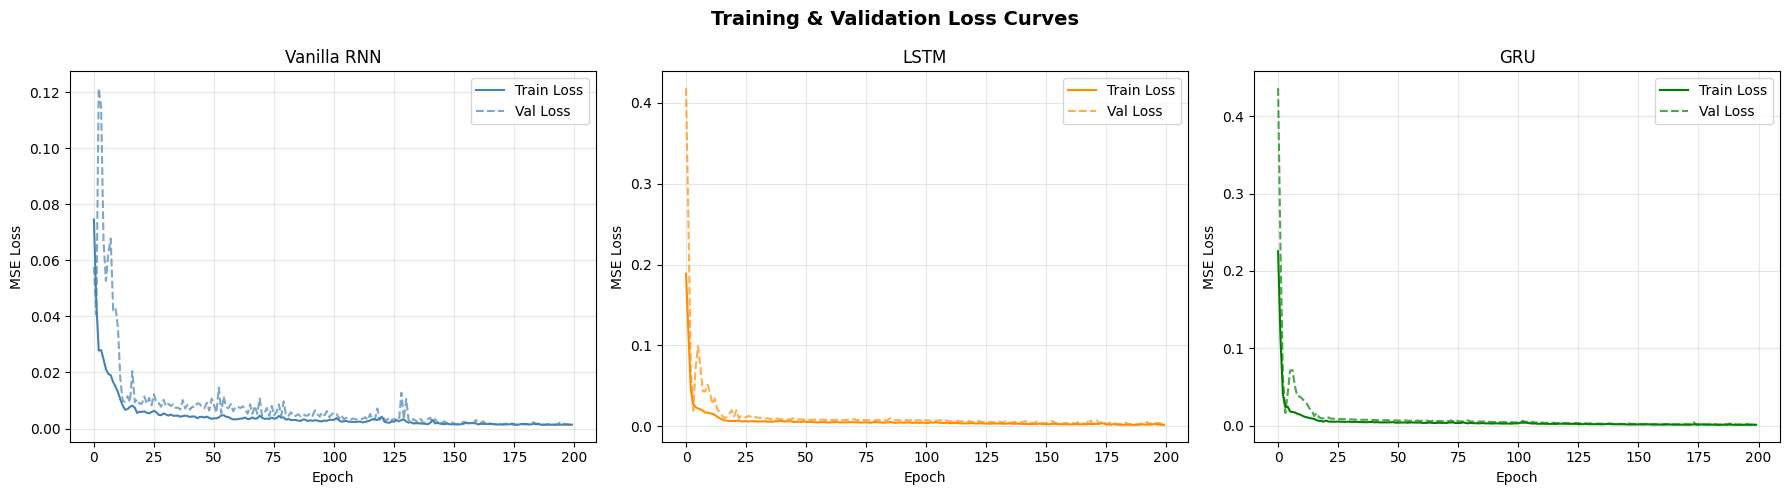

In [10]:
#Loss curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training & Validation Loss Curves', fontsize=14, fontweight='bold')
models_losses = [
    ('Vanilla RNN', rnn_train_losses, rnn_val_losses, 'steelblue'),
    ('LSTM',        lstm_train_losses, lstm_val_losses, 'darkorange'),
    ('GRU',         gru_train_losses,  gru_val_losses,  'green'),
]
for ax, (name, train_l, val_l, color) in zip(axes, models_losses):
    ax.plot(train_l, label='Train Loss', color=color, linewidth=1.5)
    ax.plot(val_l,   label='Val Loss',   color=color, linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

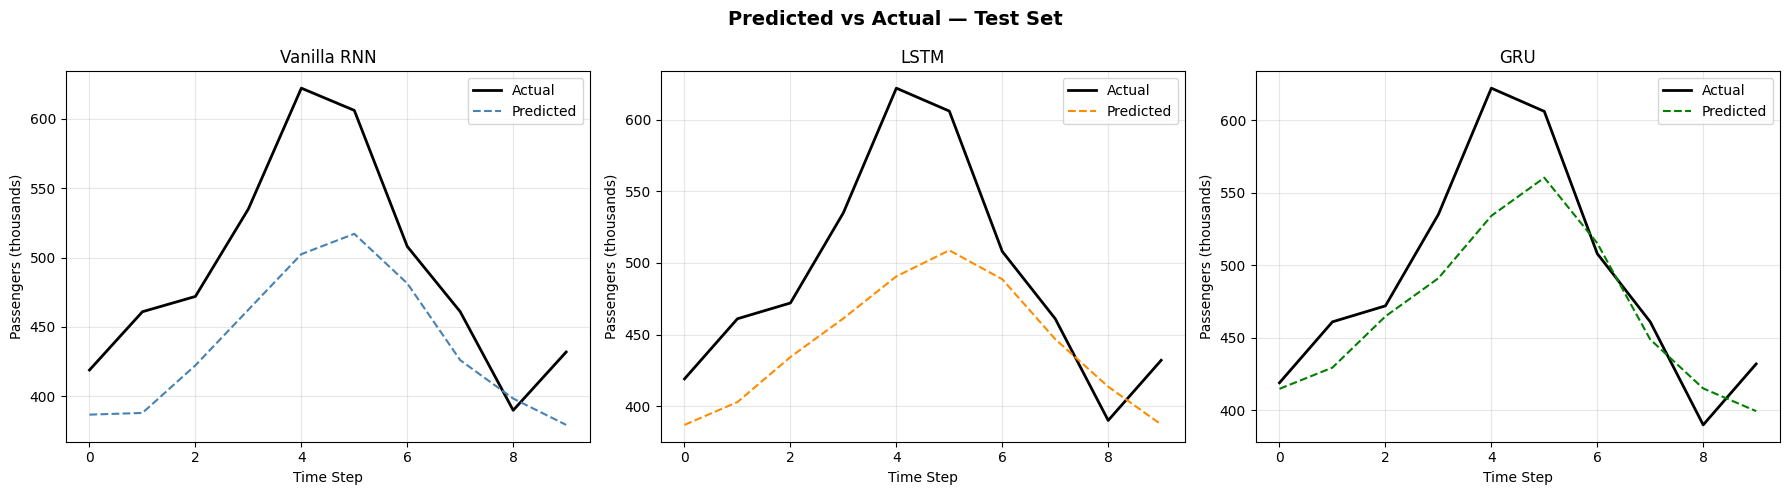

In [11]:
#Prediction comparison on test set
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Predicted vs Actual — Test Set', fontsize=14, fontweight='bold')
preds_list = [
    ('Vanilla RNN', rnn_preds,  rnn_actual,  'steelblue'),
    ('LSTM',        lstm_preds, lstm_actual, 'darkorange'),
    ('GRU',         gru_preds,  gru_actual,  'green'),
]
for ax, (name, preds, actual, color) in zip(axes, preds_list):
    ax.plot(actual, label='Actual',    color='black', linewidth=2)
    ax.plot(preds,  label='Predicted', color=color,   linewidth=1.5, linestyle='--')
    ax.set_title(name)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Passengers (thousands)')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


=== Model Comparison ===
      Model  Val RMSE  Test RMSE  Val MAE  Test MAE  Params
Vanilla RNN     28.12      64.05    24.42     55.81    4353
       LSTM     35.67      64.14    30.82     53.24   17217
        GRU     27.14      38.35    22.72     29.75   12929


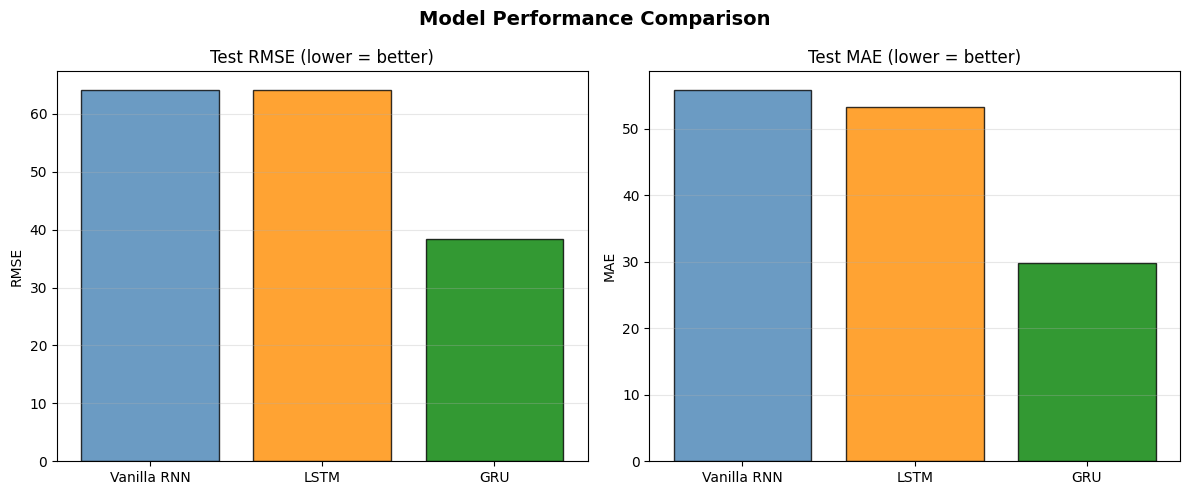

In [12]:
#Summary comparison table
results = pd.DataFrame({
    'Model': ['Vanilla RNN', 'LSTM', 'GRU'],
    'Val RMSE':  [round(rnn_val_rmse, 2),  round(lstm_val_rmse, 2),  round(gru_val_rmse, 2)],
    'Test RMSE': [round(rnn_test_rmse, 2), round(lstm_test_rmse, 2), round(gru_test_rmse, 2)],
    'Val MAE':   [round(rnn_val_mae, 2),   round(lstm_val_mae, 2),   round(gru_val_mae, 2)],
    'Test MAE':  [round(rnn_test_mae, 2),  round(lstm_test_mae, 2),  round(gru_test_mae, 2)],
    'Params':    [
        sum(p.numel() for p in rnn_model.parameters()),
        sum(p.numel() for p in lstm_model.parameters()),
        sum(p.numel() for p in gru_model.parameters()),
    ]
})
print('\n=== Model Comparison ===')
print(results.to_string(index=False))
#Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
x = np.arange(3)
colors = ['steelblue', 'darkorange', 'green']
axes[0].bar(x, results['Test RMSE'], color=colors, alpha=0.8, edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results['Model'])
axes[0].set_title('Test RMSE (lower = better)')
axes[0].set_ylabel('RMSE')
axes[0].grid(alpha=0.3, axis='y')
axes[1].bar(x, results['Test MAE'], color=colors, alpha=0.8, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results['Model'])
axes[1].set_title('Test MAE (lower = better)')
axes[1].set_ylabel('MAE')
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Analysis: Differences Between RNN, LSTM, and GRU

### Observed Differences

| Aspect | Vanilla RNN | LSTM | GRU |
|--------|-------------|------|-----|
| Memory mechanism | Single hidden state | Cell state + hidden state | Hidden state only |
| Gates | None | 3 (input, forget, output) | 2 (reset, update) |
| Handles long-range dependencies | Poor | Excellent | Good |
| Parameters | Fewest | Most | Moderate |
| Training stability | Often unstable | Very stable | Stable |

### Why These Differences Exist

**Vanilla RNN** suffers from the **vanishing gradient problem** — gradients shrink exponentially during backpropagation through time (BPTT), making it hard for the network to learn patterns spanning more than a few time steps. For 12-step sequences this may be manageable, but the `tanh` activations still compress gradients significantly.

**LSTM** was specifically designed to solve this via the **cell state highway** — a direct path for gradients to flow across many time steps. The forget gate lets the model decide what to discard, and the input gate controls what new information to store. This selective memory means LSTMs can effectively learn both short-term and long-term dependencies (e.g., year-over-year seasonal patterns in the airline data).

**GRU** achieves similar benefits to LSTM but with fewer parameters by merging the cell and hidden states and using only 2 gates. On smaller datasets like Air Passengers (144 samples), GRU often matches or outperforms LSTM because it is **less prone to overfitting** due to its simpler structure. The reduced parameter count also means faster convergence.

---
## Part 3: Can a Feed-Forward Network Solve This Problem?

**Short answer: Yes, with significant caveats — and it requires manual feature engineering to compensate for the lack of temporal modeling.**

In [13]:
class FeedForwardNet(nn.Module):
    """Flatten the sequence and pass through dense layers."""
    def __init__(self, input_size=12, hidden_size=64, output_size=1):
        super(FeedForwardNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, output_size)
        )

    def forward(self, x):
        #Flatten the sequence: (batch, seq_len, 1) -> (batch, seq_len)
        x = x.squeeze(-1)
        return self.net(x)
print('=== Feed-Forward Network ===')
ffn_model = FeedForwardNet(input_size=SEQ_LEN).to(device)
ffn_train_losses, ffn_val_losses = train_model(
    ffn_model, X_train_t, y_train_t, X_val_t, y_val_t, epochs=200
)
print('\n--- FFN Performance ---')
ffn_val_rmse, ffn_val_mae, _, _ = evaluate_model(ffn_model, X_val_t, y_val_t, scaler, 'Validation')
ffn_test_rmse, ffn_test_mae, ffn_preds, ffn_actual = evaluate_model(ffn_model, X_test_t, y_test_t, scaler, 'Test')

=== Feed-Forward Network ===
Epoch [50/200]  Train Loss: 0.003466  Val Loss: 0.002225
Epoch [100/200]  Train Loss: 0.001887  Val Loss: 0.001112
Epoch [150/200]  Train Loss: 0.002062  Val Loss: 0.000777
Epoch [200/200]  Train Loss: 0.001803  Val Loss: 0.001313

--- FFN Performance ---
Validation RMSE: 26.79  |  Validation MAE: 22.67
Test RMSE: 56.74  |  Test MAE: 52.55


       Model  Test RMSE  Test MAE
 Vanilla RNN      64.05     55.81
        LSTM      64.14     53.24
         GRU      38.35     29.75
Feed-Forward      56.74     52.55


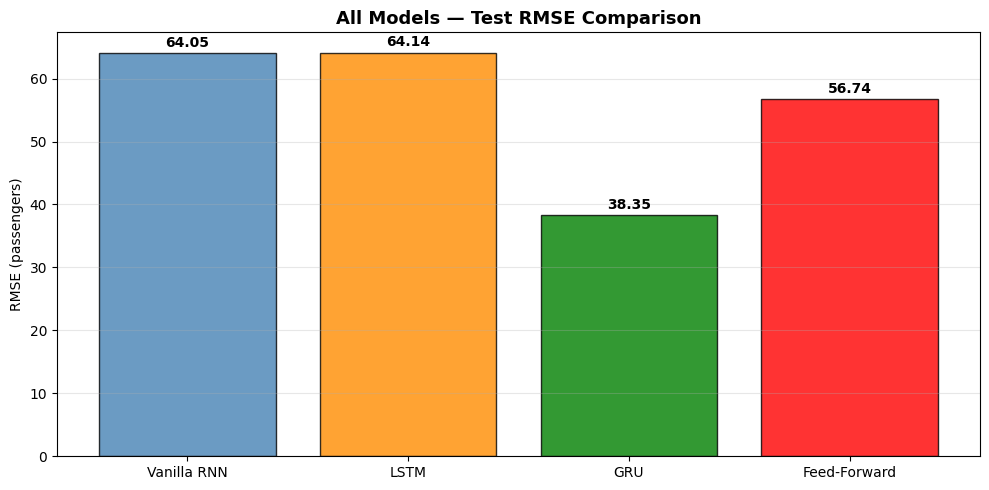

In [14]:
#Final 4-model comparison
all_results = pd.DataFrame({
    'Model': ['Vanilla RNN', 'LSTM', 'GRU', 'Feed-Forward'],
    'Test RMSE': [round(rnn_test_rmse, 2), round(lstm_test_rmse, 2),
                  round(gru_test_rmse, 2),  round(ffn_test_rmse, 2)],
    'Test MAE':  [round(rnn_test_mae, 2),  round(lstm_test_mae, 2),
                  round(gru_test_mae, 2),   round(ffn_test_mae, 2)],
})
print(all_results.to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
bars = ax.bar(x, all_results['Test RMSE'],
              color=['steelblue', 'darkorange', 'green', 'red'], alpha=0.8, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(all_results['Model'])
ax.set_title('All Models — Test RMSE Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (passengers)')
ax.grid(alpha=0.3, axis='y')
for bar, val in zip(bars, all_results['Test RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### Can FFN Solve This? Discussion

Yes, it can — but only because we already did the temporal work for it. By creating sliding-window sequences of length 12, we manually encoded the temporal structure into fixed-size feature vectors. The FFN then treats these 12 values as ordinary features with no inherent ordering.

**Key limitations of FFN for time series:**

1. **No temporal awareness:** FFN treats position 1 and position 12 symmetrically. It can't naturally learn "this value 12 steps ago matters more than 3 steps ago" the way RNNs do.
2. **Fixed input size:** The sequence length must be fixed at training time. RNNs can handle variable-length sequences.
3. **Manual feature engineering required:** Without sliding windows, lag features, rolling statistics, etc., the FFN has no way to access historical information.
4. **No sequential inductive bias:** The FFN must *learn* that the input is ordered from scratch — sequence models have this baked into their architecture.

**When FFN can work:** On this simple univariate dataset with strong periodicity (seasonality = 12 months = SEQ_LEN), the FFN may perform surprisingly well because the 12-step window captures exactly one full seasonal cycle. On more complex, longer-range sequential problems, sequence models will significantly outperform it.